In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# n is the number of instances in each class

def synthetic_data_generator(n=10,df=False):

    mean_n1= np.array([-2,2.0])
    mean_n2= np.array([0.0,0.0])

    D_n1= np.array([[1.0,0.0],[0.0,1.0]]).T
    D_n2= np.array([[1.0,1.0],[-1.0,1.0]]).T

    S_n1= np.diag([2.0,1.0])
    S_n2= np.diag([4.0,0.1])

    C_n1= np.linalg.multi_dot([D_n1,S_n1,D_n1.T])
    C_n2= np.linalg.multi_dot([D_n2,S_n2,D_n2.T])

    X1= np.random.multivariate_normal(mean_n1,C_n1,size=(n))
    X2= np.random.multivariate_normal(mean_n2,C_n2,size=(n))

    X= np.zeros((X1.shape[0] + X2.shape[0],5))
    
    X[:X1.shape[0],:2]= X1
    X[:X1.shape[0],2:-1]= np.random.uniform(-4,4,size=(X1.shape[0],2))
    X[:X1.shape[0],-1]= 1
    X[X2.shape[0]:X1.shape[0] + X2.shape[0],:2]= X2
    X[X2.shape[0]:X1.shape[0] + X2.shape[0],2:-1]= np.random.uniform(-4,4,size=(X1.shape[0],2))
    
    if (df==True):
        columns_syn= ['core_1','core_2','noise_1','noise_2','target']
        X_df= pd.DataFrame(data= X, columns= columns_syn)
        
        return X_df
    
    return X


In [15]:
X= synthetic_data_generator(n=200,df=True)

X.head()

,core_1,core_2,noise_1,noise_2,target
0,-5.247485,3.330448,1.967937,3.566985,1.0
1,-3.874035,2.884793,-2.621308,0.343735,1.0
2,-3.857889,2.573416,-0.681181,-3.972760,1.0
3,-3.225705,3.011750,-0.909293,1.339813,1.0
4,-2.217108,1.268819,1.749628,2.764512,1.0


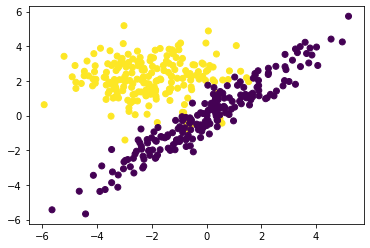

In [6]:
X= synthetic_data_generator(200)

plt.scatter(X[:,0],X[:,1],c=X[:,-1])